## DeepEcho: Industrial Audio Anomaly Detection - EDA & Preprocessing
---

### Objective
> Explore the **MIMII Pump Dataset** to identify acoustic signatures of **normal vs. abnormal** operations and define the preprocessing pipeline for a *Convolutional Autoencoder*.

### Imports & Configuration

In [75]:
import librosa as lr
import librosa.display as lrd
import matplotlib.pyplot as plt
import IPython.display as ipd
import soundfile as sf
import os

N_MELS = 128  # Number of Mel bands
DATA_PATH = '../data/raw/pump/'

### Data Integrity Check
Checking if all files have the same sampling rate and duration to ensure the pipeline doesn't encounter unexpected data formats.

In [69]:
def check_data_integrity(directory):
	sr_set = set()
	duration_set = set()

	for root, _, files in os.walk(directory):
		for file in files:
			if file.endswith('.wav'):
				file_path = os.path.join(root, file)

				with sf.SoundFile(file_path) as f:
					sr = f.samplerate
					frames = f.frames
					duration = frames / sr

				sr_set.add(sr)
				duration_set.add(round(duration, 3))

	print(f"Checked: {directory}")
	print(f"Sample Rates Found: {sr_set}")
	print(f"Durations Found: {duration_set}")
	print("-" * 40)

for machine_id in os.listdir(DATA_PATH):
	machine_path = os.path.join(DATA_PATH, machine_id)

	if not os.path.isdir(machine_path):
		continue

	check_data_integrity(os.path.join(machine_path, 'normal'))
	check_data_integrity(os.path.join(machine_path, 'abnormal'))

Checked: ../data/raw/pump/id_00/normal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_00/abnormal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_02/normal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_02/abnormal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_04/normal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_04/abnormal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_06/normal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_06/abnormal
Sample Rates Found: {16000}
D

### Comparative Visual Analysis
Comparing the waveform and Mel-Spectrogram of normal vs. abnormal samples.
- **Normal samples** typically show periodic, steady energy patterns.
- **Abnormal samples** may display transient spikes or frequency shifts in some cases, though visual detection can be challenging due to background noise.

In [70]:
def plot_comparison(normal_path, abnormal_path):
	fig, axes = plt.subplots(2, 2, figsize=(15, 10))

	for i, path in enumerate([normal_path, abnormal_path]):
		# Load audio
		waveform, sample_rate = lr.load(path, sr=None)
		label = 'Normal' if i == 0 else 'Abnormal'

		# Plot waveform
		lrd.waveshow(waveform, sr=sample_rate, ax=axes[i, 0])
		axes[i, 0].set_title(f'{label} Waveform')

		# Convert to Log-Mel Spectrogram
		mel_spec = lr.feature.melspectrogram(
			y=waveform,
			sr=sample_rate,
			n_mels=N_MELS
		)
		mel_spec_dB = lr.power_to_db(mel_spec, ref=1.0)

		# Plot spectrogram
		axes[i, 1].set_title(f'{label} Log-Mel Spectrogram')
		img = lrd.specshow(
			mel_spec_dB,
			sr=sample_rate,
			x_axis='time',
			y_axis='mel',
			ax=axes[i, 1]
		)
		fig.colorbar(img, ax=axes[i, 1], format="%+2.0f dB")

	plt.tight_layout()
	plt.show()

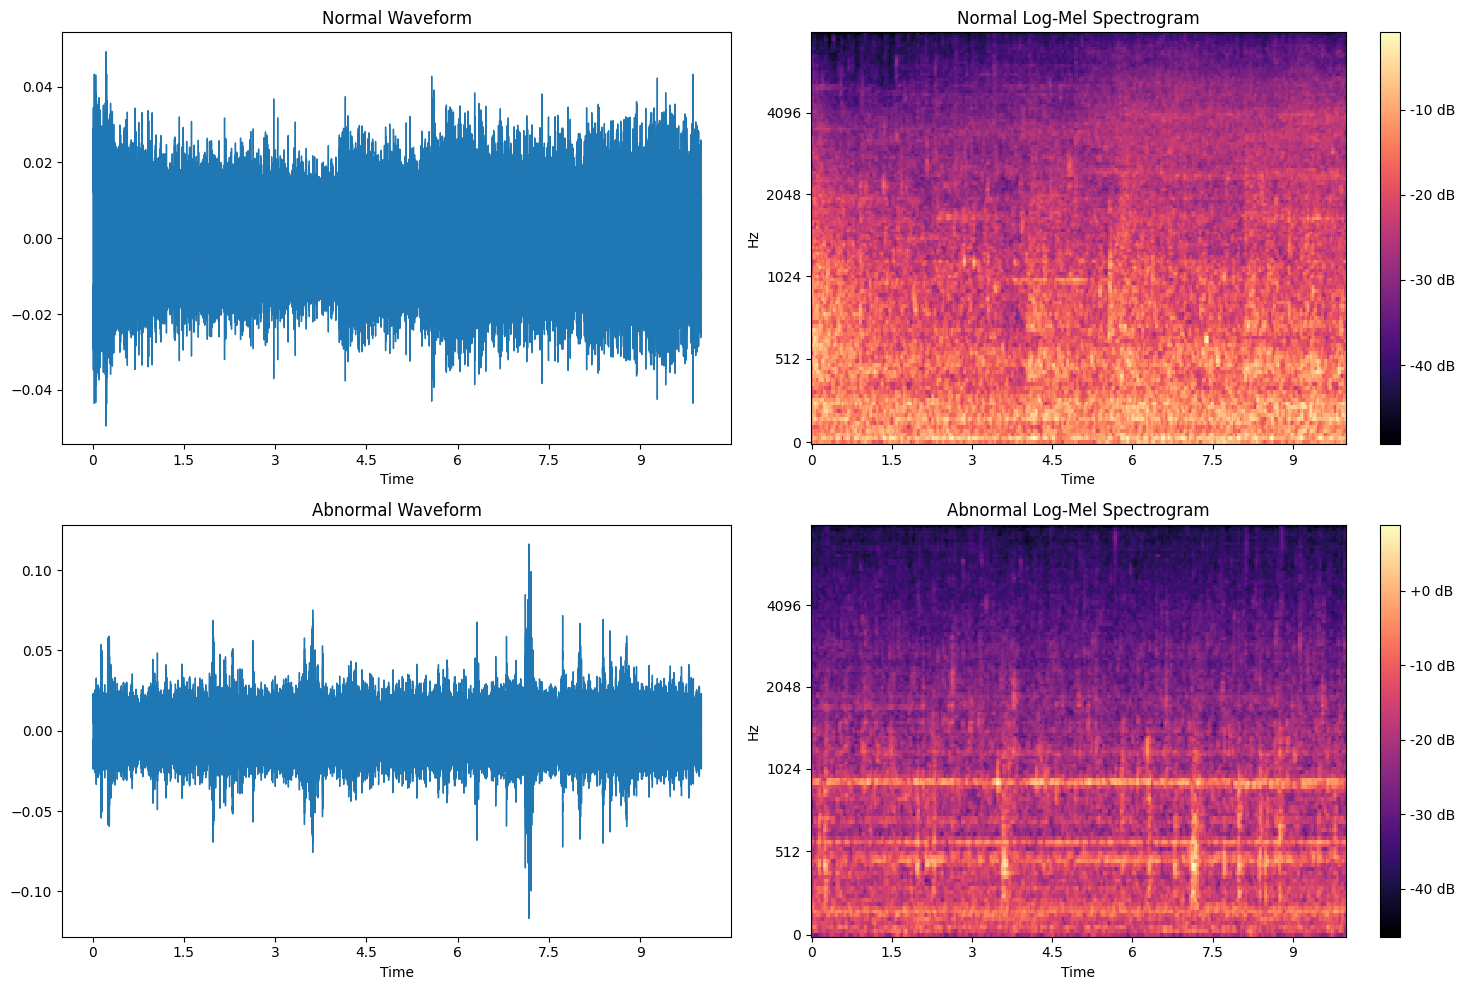

In [71]:
plot_comparison(f'{DATA_PATH}id_00/normal/00000079.wav', f'{DATA_PATH}id_00/abnormal/00000079.wav')

### Abnormal Audio

In [72]:
ipd.Audio(f'{DATA_PATH}id_00/abnormal/00000043.wav')

### Normal Audio

In [73]:
ipd.Audio(f'{DATA_PATH}id_00/normal/00000043.wav')

Some times it becomes harder to visually spot differences, but here where the neural network will help us capture subtle patterns.

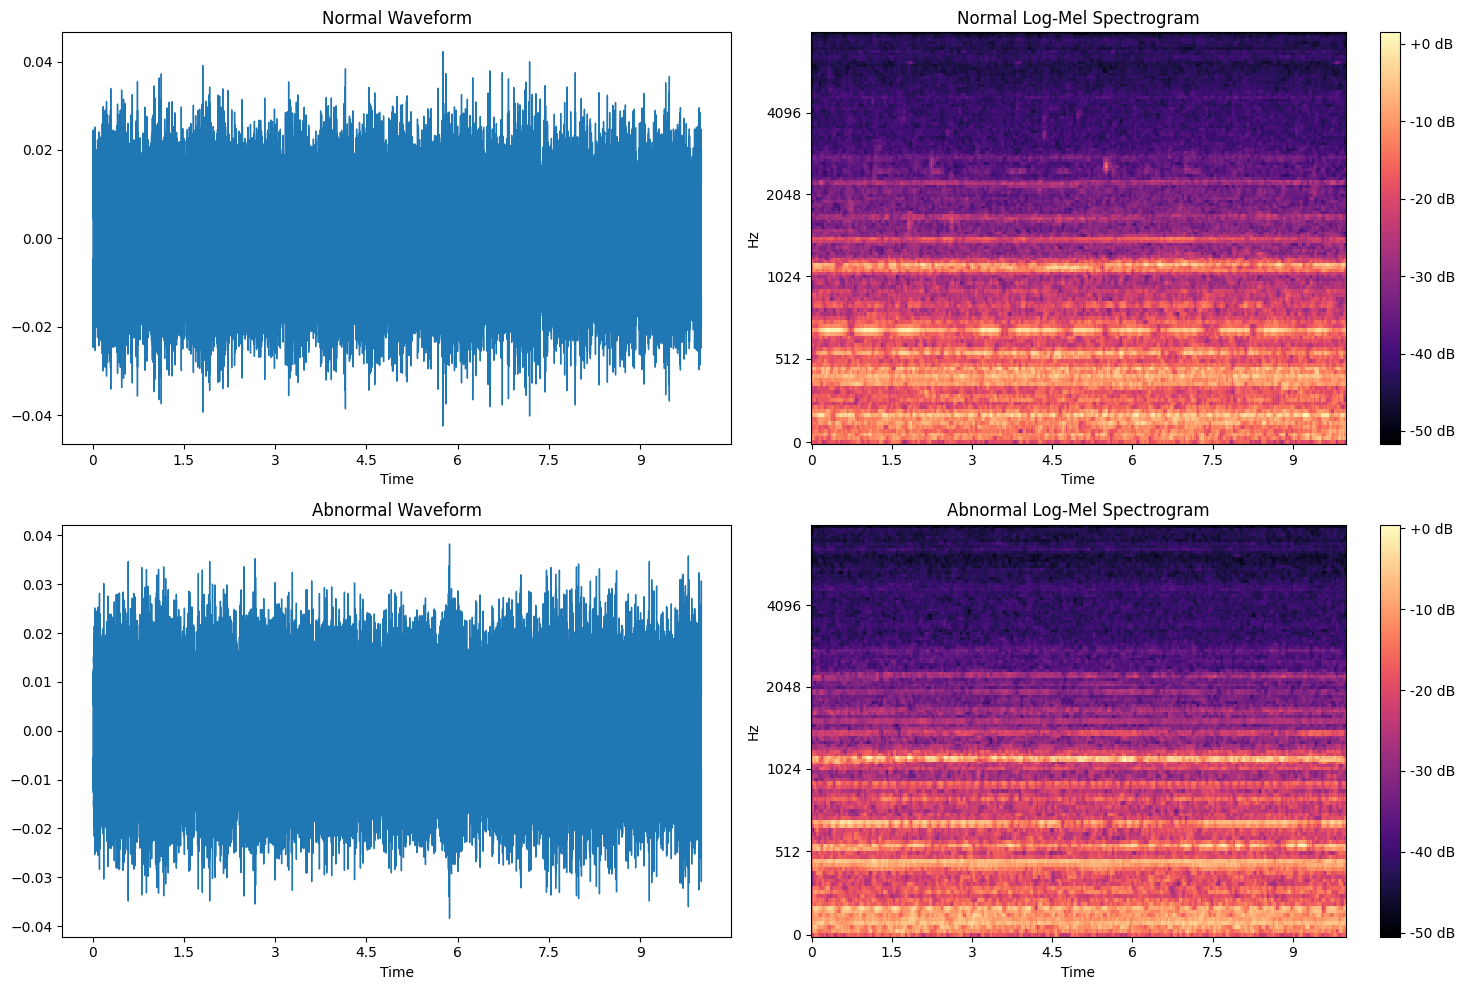

In [74]:
plot_comparison(f'{DATA_PATH}id_06/normal/00000026.wav', f'{DATA_PATH}id_06/abnormal/00000026.wav')

## Summary of Findings
- Sampling Rate: 16 kHz.
- Duration: 10 seconds.
- Challenges: Background noise is dominated by a constant fluid flow (water-like sound) which creates a stationary energy floor, making it harder to visually spot differences. However, the neural network will help us capture subtle patterns that may not be visually apparent.